# PCA Dimensionality Reduction

Principal Component Analysis (PCA) is an unsupervised learning technique that rotates high-dimensional coordinate vectors to project them onto orthogonal directions maximizing variance. This dimensionality reduction helps visualize high-dimensional data structures. This notebook generates a 4-dimensional synthetic dataset, applies PCA to reduce it to 2 dimensions, and visualizes the resulting feature coordinates.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Generate synthetic 4-dimensional dataset with 3 classes (300 samples)
np.random.seed(55)
n_samples = 300

# Base class centroid vectors
centers = [
    [2.0, -1.0, 3.0, 0.5],
    [-1.0, 2.0, 1.5, -2.0],
    [0.5, 0.5, -2.0, 1.0]
]

X_list, y_list = [], []
for label, center in enumerate(centers):
    # Add noise to construct 4D clusters surrounding centroids
    cluster_noise = np.random.normal(0, 0.6, (100, 4))
    cluster_points = center + cluster_noise
    X_list.append(cluster_points)
    y_list.append(np.full(100, label))

X = np.vstack(X_list)
y = np.concatenate(y_list)

df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2', 'Feature_3', 'Feature_4'])
df['Label'] = y
df.head(10)



,Feature_1,Feature_2,Feature_3,Feature_4,Label
0,1.025761,-1.061070,1.914125,0.657592,0
1,2.155972,-1.228652,2.998626,0.704969,0
2,2.538543,-1.216660,3.993867,-0.213406,0
3,2.999857,-2.202064,2.713276,1.321279,0
4,2.154901,-0.578589,3.533029,0.933332,0
5,1.170738,-1.596073,2.898320,0.672788,0
6,2.178235,-1.112546,2.779143,1.370468,0
7,2.131513,-0.732927,2.873637,0.195858,0
8,2.240037,-0.389492,3.726574,0.771914,0
9,1.186648,-0.522865,2.057284,-0.195872,0


## Feature Scaling & PCA Fit

Because PCA is sensitive to relative variances of features, we standard-scale input data to mean 0 and variance 1 before fitting.



In [2]:
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit PCA and reduce to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Print explained variances
variance_ratios = pca.explained_variance_ratio_
print(f"Explained Variance Ratios:")
print(f"PC 1: {variance_ratios[0]*100:.2f}%")
print(f"PC 2: {variance_ratios[1]*100:.2f}%")
print(f"Cumulative Explained Variance: {sum(variance_ratios)*100:.2f}%")



Explained Variance Ratios:
PC 1: 59.78%
PC 2: 31.81%
Cumulative Explained Variance: 91.59%


## 2D Principal Components Projection Plot

Using Matplotlib, we scatter plot the 2D principal component coordinates, coloring sample points by class label, and adding reference guidelines.



<cell>:23: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



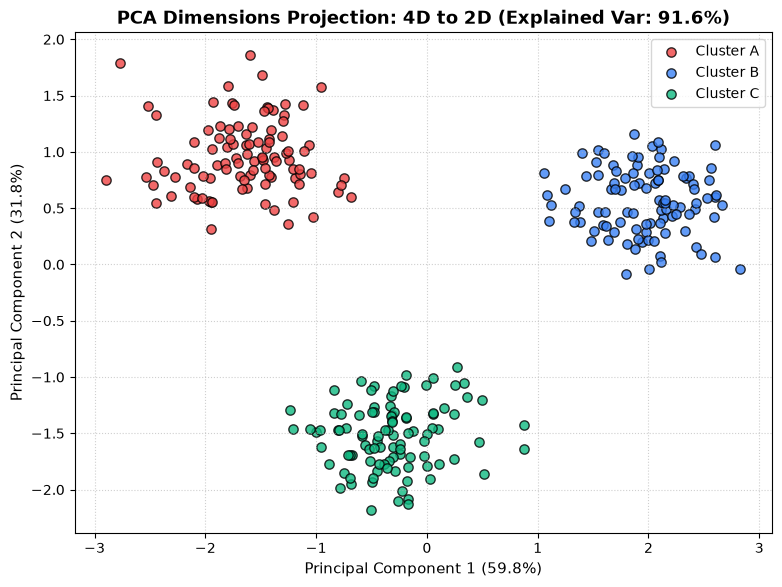

In [3]:
plt.figure(figsize=(9, 6.5))

colors = ['#EF4444', '#3B82F6', '#10B981']
class_names = ['Cluster A', 'Cluster B', 'Cluster C']

for label, color, name in zip([0, 1, 2], colors, class_names):
    indices = y == label
    plt.scatter(
        X_pca[indices, 0], 
        X_pca[indices, 1], 
        color=color, 
        label=name, 
        edgecolors='k', 
        s=45, 
        alpha=0.8
    )

plt.title(f'PCA Dimensions Projection: 4D to 2D (Explained Var: {sum(variance_ratios)*100:.1f}%)', fontsize=13, fontweight='bold')
plt.xlabel(f'Principal Component 1 ({variance_ratios[0]*100:.1f}%)', fontsize=11)
plt.ylabel(f'Principal Component 2 ({variance_ratios[1]*100:.1f}%)', fontsize=11)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()
